# Soft-IoU histograms across runs

Per-sample soft-IoU distributions as a grid: **rows are splits, columns are runs**,
plotted as densities.

Scores come from `viz.data.load_run`, the same code path the dashboard uses, so
these numbers match the viz table exactly. Each run is scored against ground
truth at **its own grid resolution**, so runs trained at different sizes are
still comparable here.

Edit `RUNS` and `SPLITS` in the config cell below and re-run.

In [1]:
import sys
from pathlib import Path

# Repo root on the path, so `viz` and `utils` import the same way the app does.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (str(ROOT), str(ROOT / "src")):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from viz.data import load_gt, load_run

%matplotlib inline

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## Config

In [2]:
# ---- edit me ----------------------------------------------------------------
RUNS = [
    "hyb-h1-transformer-conv-v1",
    "hyb-h2-boombox-full-v1",
    "hyb-h3-transformer-mlp-v1",
]

# Display names for plots and tables. A run with no entry here falls back to its
# directory name, so adding a run to RUNS never breaks the labelling.
LABELS = {
    "hyb-h1-transformer-conv-v1": "Transformer-CNN",
    "hyb-h2-boombox-full-v1": "CNN-CNN",
    "hyb-h3-transformer-mlp-v1": "Transformer-MLP",
}

def label(run: str) -> str:
    return LABELS.get(run, run)

# One row per split. Names are the directory names under
# runs/<run>/outputs_history/{train,eval/*}.
SPLITS = ["1-cube", "2-cubes", "train"]

EXPERIMENT = ROOT / "experiments" / "31_07_2026_gastronorm_exp1"
RUNS_DIR = ROOT / "runs"

# None = each run's latest saved epoch. Set an int to pin a specific one.
EPOCH = None

N_BINS = 30
# -----------------------------------------------------------------------------

## Load

Ground truth loads once and is shared across runs. Prediction tensors are a few
hundred MB per run, so this cell is the slow one (~seconds per run).

In [3]:
gt = load_gt(EXPERIMENT)
print(f"ground truth: {len(gt)} samples, primary grid {gt.masks.shape[1]}x{gt.masks.shape[2]}")

# {run: {split: iou array}}
scores: dict[str, dict[str, np.ndarray]] = {}
epochs: dict[str, int] = {}

for name in RUNS:
    if not (RUNS_DIR / name).is_dir():
        print(f"  !! {name}: no such run directory, skipping")
        continue
    rd = load_run(name, RUNS_DIR, gt, epoch=EPOCH)
    if rd.reason:
        print(f"  !! {name}: {rd.reason}")
        continue
    splits = np.asarray(rd.splits)
    scores[name] = {s: rd.iou[splits == s] for s in np.unique(splits)}
    epochs[name] = rd.epoch
    per_split = ", ".join(
        f"{s}={len(v)}" for s, v in sorted(scores[name].items()) if s in SPLITS
    )
    print(f"  {label(name)} [{name}]: epoch {rd.epoch}, "
          f"grid {rd.shape[0]}x{rd.shape[1]}, {len(rd.iou)} samples ({per_split})")

ground truth: 3007 samples, primary grid 20x40
  Transformer-CNN [hyb-h1-transformer-conv-v1]: epoch 1000, grid 21x30, 2959 samples (1-cube=112, 2-cubes=96, train=2553)
  CNN-CNN [hyb-h2-boombox-full-v1]: epoch 1000, grid 21x30, 2959 samples (1-cube=112, 2-cubes=96, train=2553)
  Transformer-MLP [hyb-h3-transformer-mlp-v1]: epoch 1000, grid 21x30, 2959 samples (1-cube=112, 2-cubes=96, train=2553)


## Summary table

Soft-IoU per run and split. `df` is a tidy DataFrame (one row per run/split);
`pivot` is the compact mean view, runs as rows and splits as columns.

In [4]:
rows = []
for name in RUNS:
    if name not in scores:
        continue
    for split in SPLITS:
        v = scores[name].get(split)
        if v is None or len(v) == 0:
            rows.append({"run": label(name), "split": split, "n": 0,
                         "mean": np.nan, "std": np.nan, "mean \u00b1 std": "--",
                         "median": np.nan, "min": np.nan, "max": np.nan,
                         "epoch": epochs.get(name)})
            continue
        mu, sd = v.mean(), v.std()
        rows.append({
            "run": label(name), "split": split, "n": len(v),
            "mean": mu, "std": sd, "mean \u00b1 std": f"{mu:.3f} \u00b1 {sd:.3f}",
            "median": float(np.median(v)), "min": v.min(), "max": v.max(),
            "epoch": epochs[name],
        })

df = pd.DataFrame(rows)
# Keep the configured orders rather than pandas' alphabetical sort.
df["run"] = pd.Categorical(df["run"], [label(r) for r in RUNS if r in scores], ordered=True)
df["split"] = pd.Categorical(df["split"], SPLITS, ordered=True)
df = df.sort_values(["run", "split"]).reset_index(drop=True)

display(df.style.format({c: "{:.4f}" for c in ["mean", "std", "median", "min", "max"]},
                        na_rep="--").hide(axis="index"))

# Compact view: runs as rows, splits as columns, cells as "mean +- std".
pivot = df.pivot(index="run", columns="split", values="mean \u00b1 std")
display(pivot.style.set_caption("soft-IoU (mean \u00b1 std)"))

run,split,n,mean,std,mean ± std,median,min,max,epoch
Transformer-CNN,1-cube,112,0.0822,0.0788,0.082 ± 0.079,0.0604,0.0000,0.3804,1000
Transformer-CNN,2-cubes,96,0.1744,0.1133,0.174 ± 0.113,0.1670,0.0000,0.4290,1000
Transformer-CNN,train,2553,0.9744,0.1077,0.974 ± 0.108,0.9868,0.0012,0.9952,1000
CNN-CNN,1-cube,112,0.2058,0.1639,0.206 ± 0.164,0.1880,0.0006,0.7942,1000
CNN-CNN,2-cubes,96,0.2538,0.1333,0.254 ± 0.133,0.2572,0.0003,0.4940,1000
CNN-CNN,train,2553,0.9823,0.1089,0.982 ± 0.109,0.9946,0.0002,0.9975,1000
Transformer-MLP,1-cube,112,0.1526,0.1179,0.153 ± 0.118,0.1257,0.0053,0.4867,1000
Transformer-MLP,2-cubes,96,0.2026,0.1291,0.203 ± 0.129,0.1579,0.0004,0.4666,1000
Transformer-MLP,train,2553,0.8674,0.1007,0.867 ± 0.101,0.8813,0.0000,0.9529,1000


split,1-cube,2-cubes,train
run,,,
Transformer-CNN,0.082 ± 0.079,0.174 ± 0.113,0.974 ± 0.108
CNN-CNN,0.206 ± 0.164,0.254 ± 0.133,0.982 ± 0.109
Transformer-MLP,0.153 ± 0.118,0.203 ± 0.129,0.867 ± 0.101


## Histograms

Rows are splits, columns are runs -- one panel per (split, run) pair.

`density=True`, so each panel integrates to 1 and the y-axis is a probability
density rather than a raw count. That is what makes the panels comparable: the
splits have very different sample counts (~2553 train vs ~112 1-cube), and raw
counts would make the shapes unreadable side by side. The n is printed in each
panel title.

The dashed line is the mean, labelled on the plot along with the std; the grey
band spans +/-1 std. Within a row the y-axis is shared, so the panels of one
split are directly comparable to each other; each row gets its own scale.

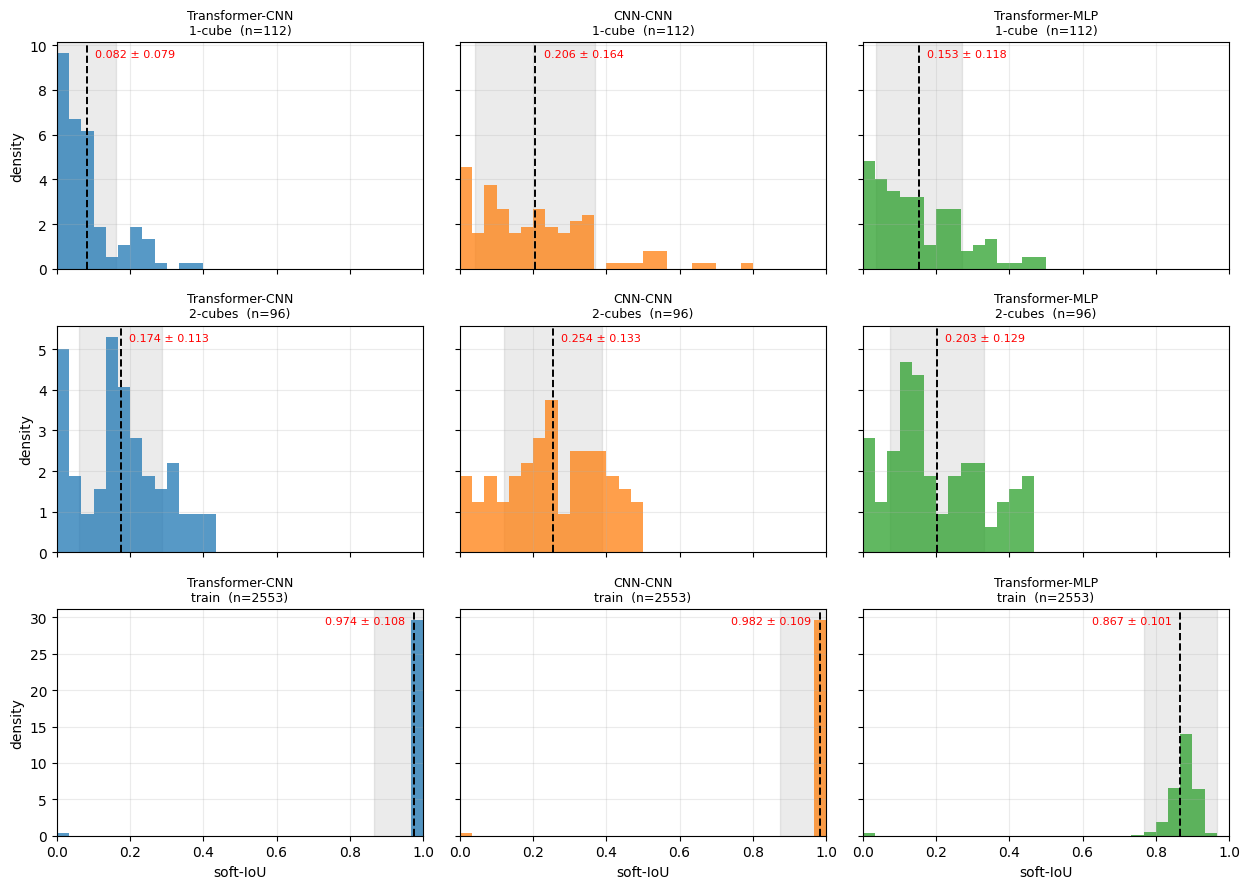

In [8]:
# Shared bins across every run and split -- soft-IoU is bounded to [0,1], so a
# fixed edge set keeps bar widths identical across every panel.
bins = np.linspace(0.0, 1.0, N_BINS + 1)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
present = [n for n in RUNS if n in scores]

n_rows, n_cols = len(SPLITS), len(present)

# squeeze=False so axes is always 2D -- indexing stays uniform for a single
# run or a single split.
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4.2 * n_cols, 3.0 * n_rows),
    sharex=True, sharey="row", squeeze=False,
)

for r, split in enumerate(SPLITS):
    for c, name in enumerate(present):
        ax = axes[r][c]
        v = scores[name].get(split)
        if v is None or len(v) == 0:
            ax.text(0.5, 0.5, "no data", ha="center", va="center",
                    transform=ax.transAxes, color="0.5", fontsize=9)
            ax.set_title(f"{label(name)}\n{split}", fontsize=9)
            continue

        mu, sd = v.mean(), v.std()
        ax.hist(v, bins=bins, density=True, color=colors[c % len(colors)], alpha=0.75)

        # +/-1 std band behind the mean line, so spread is readable at a glance
        # and not only from the printed number.
        ax.axvspan(mu - sd, mu + sd, color="k", alpha=0.08, zorder=0)
        ax.axvline(mu, color="k", linestyle="--", linewidth=1.4)

        # Label the mean on the plot itself. Placed in axes coords on whichever
        # side of the line has more room, so it never runs off the panel edge.
        left = mu > 0.5
        ax.annotate(
            f"{mu:.3f} \u00b1 {sd:.3f}",
            xy=(mu, 0.97), xycoords=("data", "axes fraction"),
            xytext=(-6 if left else 6, 0), textcoords="offset points",
            ha="right" if left else "left", va="top", fontsize=8,
            color='red',
            # bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
            #           edgecolor="0.7", alpha=0.85),
        )

        ax.set_title(f"{label(name)}\n{split}  (n={len(v)})", fontsize=9)
        ax.grid(alpha=0.25)

        if c == 0:
            ax.set_ylabel("density")
        if r == n_rows - 1:
            ax.set_xlabel("soft-IoU")

axes[0][0].set_xlim(0, 1)
fig.tight_layout()
plt.show()

## Overlaid, one figure per split

The same distributions stacked on shared axes, for reading the runs against each
other directly rather than panel by panel.

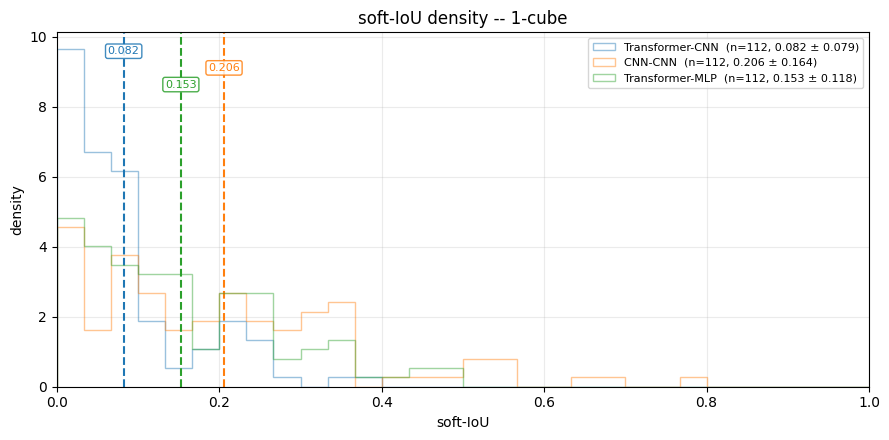

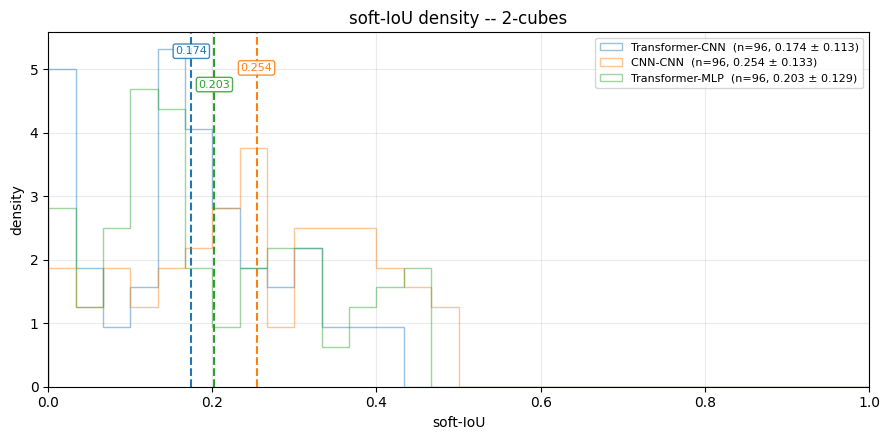

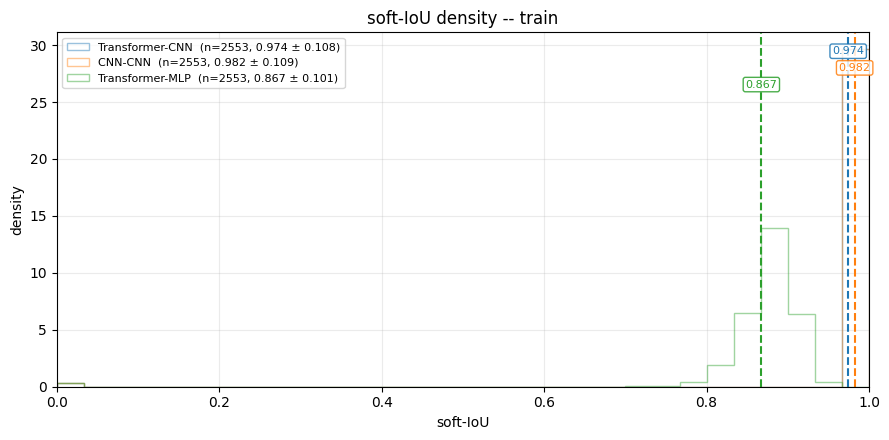

In [6]:
for split in SPLITS:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    drew = False
    for i, name in enumerate(present):
        v = scores[name].get(split)
        if v is None or len(v) == 0:
            continue
        mu, sd = v.mean(), v.std()
        ax.hist(v, bins=bins, density=True, alpha=0.45, histtype='step',
                label=f"{label(name)}  (n={len(v)}, {mu:.3f} \u00b1 {sd:.3f})",
                color=colors[i % len(colors)])
        ax.axvline(mu, color=colors[i % len(colors)], linestyle="--", linewidth=1.5)
        # Stagger the labels down the top edge so overlapping means stay legible.
        ax.annotate(f"{mu:.3f}", xy=(mu, 1.0), xycoords=("data", "axes fraction"),
                    xytext=(0, -10 - 12 * i), textcoords="offset points",
                    ha="center", va="top", fontsize=8,
                    color=colors[i % len(colors)],
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                              edgecolor=colors[i % len(colors)], alpha=0.85))
        drew = True

    if not drew:
        plt.close(fig)
        print(f"no data for split {split!r}")
        continue

    ax.set_title(f"soft-IoU density -- {split}")
    ax.set_xlabel("soft-IoU")
    ax.set_ylabel("density")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()